# 회귀와 평가지표

1. 회귀란 무엇인가?
2. 같은 피처, 정답만 바꾸면 어떻게될까?
3. 회귀의 다양한 알고리즘.
4. 회귀 평가지표(MAE, MSE, RMSE, R^2)
5. 잔차분석

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED, time_split, load_merged

setup()
pd.set_option("display.width", 130)

df = build_dataset()            
train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

X_train, X_test = tr[FEATURES], te[FEATURES]

y_train_분류, y_test_분류 = tr["target_up"], te["target_up"]
y_train_회귀, y_test_회귀 = tr["target_ret"], te["target_ret"]


print(f" 학습 {len(tr):,}행 ({tr.date.min().date()} ~ {tr.date.max().date()})")
print(f" 테스트 {len(te):,}행 ({te.date.min().date()} ~ {te.date.max().date()})")
print(f" 피처 {len(FEATURES)}개")
print()
print(f"분류용 target_up : {y_train_분류.unique()} (범주)")
print(f"회귀용 target_ret : {y_train_회귀.min():.4f} ~ {y_train_회귀.max():.4f} (수치)")

[폰트] Malgun Gothic / unicode_minus=False
 학습 15,000행 (2023-10-24 ~ 2026-01-16)
 테스트 4,000행 (2026-01-19 ~ 2026-08-07)
 피처 7개

분류용 target_up : [0 1] (범주)
회귀용 target_ret : -0.2260 ~ 0.2313 (수치)


---
# 회귀란 무엇인가?
> 수치를 예측하는 문제다.

||분류|회귀|
|---|---|---|
|예측|up/down|2.7|
|맞다/틀리다|명확함|개념이 없음|
|평가|몇 개를 맞혔냐|얼마나 빗나갔나|

### 정확하게 맞혔다가 없다!
수익률을 2.7%로 예측했는데 2.71%가 나오면 맞힌걸까? 틀린건가?

둘 다 아니다. 회귀에서는 얼마나 가까운가? 그것이 중요하다. 오차의 크기를 잰다.

**로지스틱회귀는 분류모델이다**

내부에서 선형 회귀를 계산한 뒤에 그 값을 0~1확률로 넘기기 때문에 분류로 한다.

---
# 같은 피처, 정답만 바꾸면 어떻게될까?

피처는 그대로두고 y먼 변경한다.

분류 y = target_up (0/1) -> RandomForestClassifier
회귀 y = target_ret (수익률) -> RandomForestRegressor

**같은 알고리즘인데 평가 방법이 완전히 달라진다.**

In [2]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

# 이름 끝만 다르다. RandomForestClassifier, RandomForestRegressor
clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)
reg = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)

clf.fit(X_train, y_train_분류)
reg.fit(X_train, y_train_회귀)

pred_분류 = clf.predict(X_test)
pred_회귀 = reg.predict(X_test)

print(f"{'':<14}{'분류':<32}{'회귀'}")
print("-"*70)
print(f"{'정답예시':<13}{str(y_test_분류.iloc[0]):32}{y_test_회귀.iloc[0]:.4f}")
print(f"{'예측예시':<13}{str(pred_분류[0]):32}{pred_회귀[0]:.4f}")
print()
print(f"분류평가 정확도 {accuracy_score(y_test_분류, pred_분류):.4f}"
      f"    F1  {f1_score(y_test_분류, pred_분류):.4f}")
print(f"회귀평가 RMSE {np.sqrt(mean_squared_error(y_test_회귀, pred_회귀)):.6f}"
      f"    R^2  {r2_score(y_test_회귀, pred_회귀):.4f}")



              분류                              회귀
----------------------------------------------------------------------
정답예시         0                               -0.0068
예측예시         1                               -0.0000

분류평가 정확도 0.4933    F1  0.4269
회귀평가 RMSE 0.027389    R^2  -0.0068


In [3]:
# 회귀 예측을 0 기준으로 잘라서 분류로 변경하면?

회귀를_분류로 = (pred_회귀 > 0).astype(int)

print(f"회귀 모델 예측을 0 기준으로 자른 정확도 : "
      f"{accuracy_score(y_test_분류, 회귀를_분류로):.4f}")
print(f"처음부터 분류로 학습한 정확도 : "
      f"{accuracy_score(y_test_분류, pred_분류):.4f}")
print()

# 비슷하게 나온다. 같은 정보를 다르게 요약한 것이기 때문에 
# 다만 회귀는 '얼마나'를 알려주고, 분류는 '어느 쪽인지'만 알려준다.

회귀 모델 예측을 0 기준으로 자른 정확도 : 0.4793
처음부터 분류로 학습한 정확도 : 0.4933



**값의 형태가 다르기 때문에 평가지표를 섞어 쓸 수는 없다**

회귀모델에 정확도를 물을 수 있을까? -> 2.7%예상했는데 2.71%이라면 애~~매하다.

분류에서는 혼동행렬로 TP,FN를 셌다. 회귀에는 셀 것이 없다. 대신 예측값과 실제값의 차이(잔차)를 어떻게 요약해서 볼것인가?

---
# LinearRegression

가장 단순한 선형 회귀 모델이다. **직선으로 관례를 표현**한다.

```
예측값 = w1*수익률 + w2*이동평균비율 + w3*변동성 + ... + b
```

학습이란 **오차가 가장 작아지는 w와 b를 찾는 것**이다.

w = 가중치,
b = 편향

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 계수를 비교하려면 스케일링이 먼저입니다.
lin = Pipeline([("sc", StandardScaler()), ("m", LinearRegression())])
lin.fit(X_train, y_train_회귀)

# lin.named_steps["m"] : 머신러닝 파이프라인 객체에서 이름이 m으로 지정된 모델을 가져온다.
# 모델.coef_는 가중치 배열
계수 = pd.Series(lin.named_steps["m"].coef_, index=FEATURES).sort_values()
# 모델.intercept_ 편향 값
절편 = lin.named_steps["m"].intercept_

print(f"절편 (b) : {절편:.6f}")
print()
print("계수 (w) : ")
print(계수.round(6).to_string())

절편 (b) : -0.000063

계수 (w) : 
vol20          -0.000567
ma20_ratio     -0.000507
volume_ratio   -0.000161
range_pct       0.000055
ma5_ratio       0.000117
ret_5d          0.000544
ret_1d          0.000756


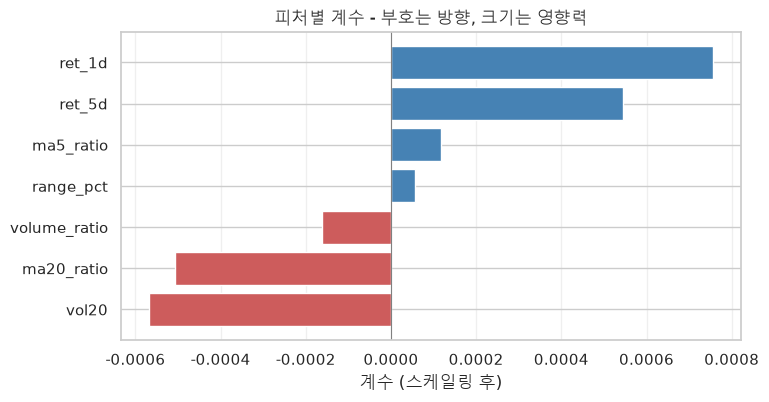

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

colors = ["indianred" if v < 0 else "steelblue" for v in 계수.values]

ax.barh(계수.index, 계수.values, color=colors)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("계수 (스케일링 후)")
ax.set_title("피처별 계수 - 부호는 방향, 크기는 영향력")
ax.grid(alpha=0.3, axis="x")
plt.show()

**계수가 해석을 도와준다**

w가 크면 그 피처가 예측에 크게 기여한다라는 뜻이고, 부호는 방향을 알려준다.

다만 스케일이 다르면 계수 크기를 직접 비교할 수 없기때문에 스케일링을 먼저 해줘야한다.

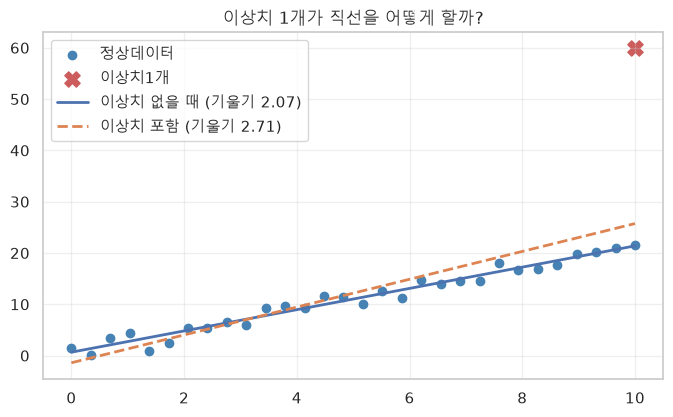

In [6]:
# 이상치 하나 넣어서 어느정도 끌려가는지 보자

rng = np.random.default_rng(SEED) # 난수생성기
x_demo = np.linspace(0, 10, 30) # 0~10까지 범위를 균등하게 30개 구간으로 나눈 숫자배열
# 실제 데이터처럼 생성
# + 노이즈(평균0, 표준편차 1.5인 오차 30개)
y_demo = 2 * x_demo + 1 + rng.normal(0, 1.5, 30) 

x_bad = np.append(x_demo, 10)
y_bad = np.append(y_demo, 60)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x_demo, y_demo, label="정상데이터", color="steelblue")
ax.scatter([10], [60], s=120, label="이상치1개", color="indianred", marker="X", zorder=-5)

for xs, ys, style, label in [
    (x_demo, y_demo, "-", "이상치 없을 때"),
    (x_bad, y_bad, "--", "이상치 포함"),
]:
    m = LinearRegression().fit(xs.reshape(-1, 1), ys)
    xx = np.linspace(0, 10, 10)
    ax.plot(xx, m.predict(xx.reshape(-1, 1)), style, lw=2,
            label=f"{label} (기울기 {m.coef_[0]:.2f})")


ax.legend()
ax.grid(alpha=0.3)
ax.set_title("이상치 1개가 직선을 어떻게 할까?")
plt.show()


**이상치 한개가 직선을 끌고간다**

선형회귀는 오차의 제곱을 최소화합니다. 크게 빗나간 점 하나가 제곱되면서 영향력이 커진다.

---
# 규제회귀 - Ridge, Lasso, ElasticNet

피처가 많아지며 모델이 학습 데이터의 잡음까지 외운다. 계수가 비정상적으로 커지면서 과적합이 일어난다.
규제는 계수가 커지는 것에 벌점을 줘서 이를 막는 것이다.

||Ridge(L2)|Lasso(L1)|ElasticNet|
|---|---|---|---|
|벌점|계수의 제곱|계수의 절댓값|둘을 섞음|
|효과|계수를 작게|일부를 0으로|중간|
|결과|모든 피처 유지|피처 선택 효과| 상관된 피처에 강함 |

In [7]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

def make(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])

# 규제회귀의 alpha(규제강도)가 커질수록 모델의 복잡도가 낮아지고 과적합을 방지, 다만 너무 커지면 미달적합이 발생한다.
models = {
    "Linear": make(LinearRegression()),  # 기본선형회귀
    "Ridge(a=1)": make(Ridge(alpha=1.0)), # 규제강도 약한 Ridge -> 가중치를 조금 줄인모델
    "Ridge(a=1000)": make(Ridge(alpha=1000)), # 규제강도 매우강한 Ridge -> 가중치를 거의 0에 가깝게 줄인모델
    "Lasso(a=1e-4)": make(Lasso(alpha=1e-4)), # 아주약한  Lasso -> 가중치를 조금 줄인모델
    "Lasso(a=1e-3)": make(Lasso(alpha=1e-3)), # 조금더강한 Lasso -> 불필요한 특성의 계수를 0으로 만들어서 제거할 수 있다.
    "ElasticNet": make(ElasticNet(alpha=1e-4, l1_ratio=0.5)),
}

rows = {}
for name, m in models.items():
    m.fit(X_train, y_train_회귀)
    rows[name] = m.named_steps["m"].coef_

rows_df = pd.DataFrame(rows, index=FEATURES)
print(rows_df.round(6).to_string())

print()
for col in ["Lasso(a=1e-4)", "Lasso(a=1e-3)"]:
    d = [f for f, v in rows_df[col].items() if v == 0]
    print(f"{col:<16} 0이 된 피처 {len(d)}개 {d}")



                Linear  Ridge(a=1)  Ridge(a=1000)  Lasso(a=1e-4)  Lasso(a=1e-3)  ElasticNet
ret_1d        0.000756    0.000756       0.000657       0.000659            0.0    0.000707
ret_5d        0.000544    0.000544       0.000380       0.000132            0.0    0.000339
ma5_ratio     0.000117    0.000117       0.000235       0.000133            0.0    0.000124
ma20_ratio   -0.000507   -0.000506      -0.000392      -0.000058            0.0   -0.000282
vol20        -0.000567   -0.000567      -0.000528      -0.000460            0.0   -0.000510
volume_ratio -0.000161   -0.000161      -0.000151      -0.000058            0.0   -0.000107
range_pct     0.000055    0.000055       0.000046       0.000000            0.0    0.000000

Lasso(a=1e-4)    0이 된 피처 1개 ['range_pct']
Lasso(a=1e-3)    0이 된 피처 7개 ['ret_1d', 'ret_5d', 'ma5_ratio', 'ma20_ratio', 'vol20', 'volume_ratio', 'range_pct']


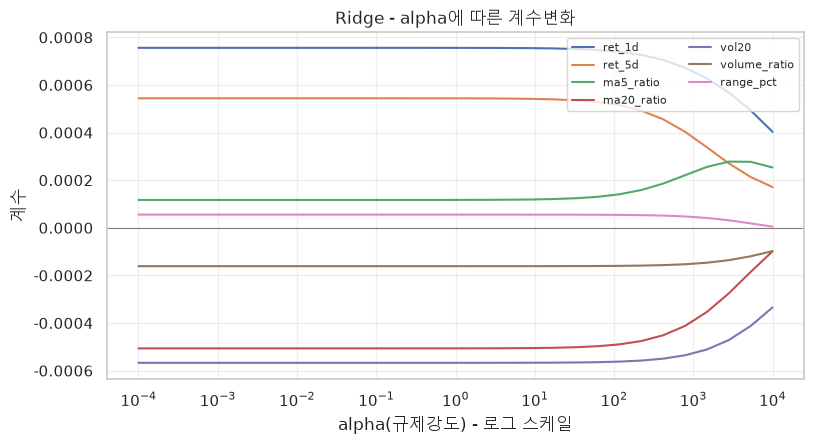

In [8]:
# alpha를 키우면 계수가 어떻게 줄어드는지 직접확인하면 진행

alphas = np.logspace(-4, 4, 30) # 0.0001~10000까지 로그 스케일간격으로 30개의 alpha후보 생성
path = []

for a in alphas:
    m = make(Ridge(alpha=a))
    m.fit(X_train, y_train_회귀)
    path.append(m.named_steps["m"].coef_)

path = np.array(path)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, f in enumerate(FEATURES):
    ax.plot(alphas, path[:, i], label=f)

ax.set_xscale("log")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("alpha(규제강도) - 로그 스케일")
ax.set_ylabel("계수")
ax.set_title("Ridge - alpha에 따른 계수변화")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.show()



**alpha를 너무 키우면 과소적합이 된다.**

규제가 강해질수록 계수가 전부 0에 가까워지고, 아무것도 학습할 수 없다. 그림과같이 0으로 전부 수렴한다.

적절한 값은 데이터마다 다르다.

**Lasso는 피처를 골라준다.**
불필요한 피처의 계수를 아예 0으로 만들어 모델에서 제외한다. 위 표에서 a=1e-4는 일부만 떨어뜨리고 크게 없애는 값이 없지만 a=le-3일 때는 전부 0으로 만들었다.

alpha값은 계수의 크기에 맞춰 정해야한다.


---

# KNN회귀와 RandomForestRegressor

> RandomForestClassifier -> 다수결
>
> RandomForestRegressor -> 평균


> KNeighborsClassifier -> 주변 K개의 다수결로 범주 결정
>
> KNeighborsRegressor -> 주변 K개의 평균으로 수치를 결정

In [10]:
from sklearn.neighbors import KNeighborsRegressor

models = {
    "기본값(평균)" : None,
    "LinearRegression" : make(LinearRegression()),
    "Ridge(alpha=1.0)": make(Ridge(alpha=1.0)),
    "Lasso(alpha=1e-4)" : make(Lasso(alpha=1e-4)),
    "KNN(K=50)" : make(KNeighborsRegressor(n_neighbors=50, n_jobs=-1)),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=100, n_jobs=-1,
                              random_state=SEED, max_depth=6)
}

rows = []
predics = {}

for name, m in models.items():
    if m is None:
        #학습 데이터의 평균으로만 예측하는 가장 단순한 방식
        p = np.full(len(y_test_회귀), y_test_회귀.mean())
        predic_r2 = np.nan
    else:
        m.fit(X_train, y_train_회귀)
        p = m.predict(X_test)
        # R^2 : 데이터의 변동성을 얼마나 잘 설명하는지 0~1로 나타낸 평가지표 
        predic_r2 = m.score(X_train, y_train_회귀)

    predics[name] = p
    rows.append({
        "모델" : name,
        "MAE" : mean_absolute_error(y_test_회귀, p),
        "RMSE" : np.sqrt(mean_squared_error(y_test_회귀, p)),
        "R^2(테스트)" : r2_score(y_test_회귀, p),
        "R^2(학습)" : predic_r2,
    })

print(pd.DataFrame(rows).round(6).to_string(index=False))


                   모델      MAE     RMSE  R^2(테스트)  R^2(학습)
              기본값(평균) 0.017889 0.027297  0.000000      NaN
     LinearRegression 0.017925 0.027317 -0.001506 0.001950
     Ridge(alpha=1.0) 0.017925 0.027317 -0.001506 0.001950
    Lasso(alpha=1e-4) 0.017922 0.027313 -0.001204 0.001777
            KNN(K=50) 0.018125 0.027621 -0.023880 0.024733
RandomForestRegressor 0.017967 0.027389 -0.006779 0.051433


### R^2 = 1 - (모델의 오차) / (평균으로 예측했을 때의 오차)

|R^2|의미|
|1.0|완벽|
|0.7|분산의 70%를 설명|
|0.0|평균으로 찍는것과 동일|
|음수|평균보다 못하다|

평균으로 찍는 R2가 0인 것은 당연하다.
다른 모델이 이것보다 좋은지를 봐야한다.

우리데이터를 보면 모든 모델이 평균보다 못하다.

-> 주가예측은 원래 어렵다. R2가 0.05만 나와도 괜찮은 값이 된다.

-> 금융 시계열 데이터는 배부분 예측 서로의 영향을 많이 받는 예측불가능한 데이터다.

---
# 평가지표 - MAE MSE RMSE R^2

모두 잔차(실제값 - 예측값)를 가지고 구한 것들이다

|지표|계산|특징|
|---|---|---|
|MAE|잔차 절대값 평균|해석이 직관적, 이상치에 덜민감|
|MSE|잔차 제곱의 평균|큰 오차에 큰 벌점, 단위가 제곱|
|RMSE|MSE의 제곱근|MSE장점 + 원래단위|
|R^2|평균대비모델점수|단위가 없어서 모델간 비교가 쉬움|

In [12]:
# MAE와 RMSE

error = np.array([1, 1, 1, 10])
print(f"오차가 {error.tolist()}일 때")
print(f"MAE = {('+'.join(map(str, error)))} / 4 = {error.mean():.2f}")
print(f"RMSE = 루트({'+'.join(str(e**2) for e in error)} / 4) = {np.sqrt((error**2).mean()):.2f} ")



오차가 [1, 1, 1, 10]일 때
MAE = 1+1+1+10 / 4 = 3.25
RMSE = 루트(1+1+1+100 / 4) = 5.07 


> RMSE가 더 크다 -> 제곱하기때문에 큰 오차를 더 크게 벌한다.  
> 가끔 크게 틀리는 것이 치명적 -> RMSE  
> 대체로 얼마나 빗나가는지 -> MAE

**MSE는 보고 판단하지 말자**
단위가 제곱이라 해석이 안된다.  RMSE의 중간단계로 알아만두자.


In [ ]:
# RMSE

best = min(rows, key=lambda r: r["RMSE"])

print(f" 가장 나은 모델 : {best['모델']}")
print(f" RMSE {best['RMSE']:.6f} = 수익률 예측이 평균 {best['RMSE']*100:.2f}% 빗나감")
print(f" MAE {best['MAE']:.6f} = 평균 {best['MAE']*100:.2f}% 빗나감")
print()

#표준편차 = 아무것도 건들지않은 평균치
print(f" 실제 수익률의 표준편차 : {y_test_회귀.std()*100:.2f}%")

# 오차가 데이터 자체의 변동폭과 비슷할 것이다.
# 사실상 거의 설명하지 못하고 있다는 뜻이다.
# 둘의 차이가 없다면 머신러닝을 사용해서 조금의 이점을 가지고가는것보다 평균을 쓰면된다.

print()
print("지표비교")
print(f"{'':<12}{'분류':<20}{'회귀'}")
print(" " + "-" *50)
print(f" {'기본':<12}{'정확도':<20}{'R^2'}")
print(f" {'오차크기':<12}{'-':<20}{'MAE, RMSE'}")
print(f" {'종합비교':<12}{'AUC':<20}{'R^2'}")
print(f" {'세부진단':<12}{'혼동행렬':<20}{'잔차분석'}")


 가장 나은 모델 : 기본값(평균)
 RMSE 0.027297 = 수익률 예측이 평균 2.73% 빗나감
 MAE 0.017889 = 평균 1.79% 빗나감

 실제 수익률의 표준편차 : 2.73%


---
# 잔차분석

숫자 하나로 요약된 지표는 어디서 틀렸는지 보여주지않는다. 잔차를 직접 확인해봐야 알 수 있다.  

```
residual = y_test - pred
```  

|그래프|정상|이상|
|---|---|---|
|예측값 vs 잔차|0주변에 무작위|패턴이 보임|
|잔차 히스토그램|0 중심 종 모양|치우침|
|실제 vs 예측|대각선에 밀집|벗어남| 


In [ ]:
pred_best = predics["RandomForestRegressor"]
residual = y_test_회귀.values - pred_best

print(f"잔차 = 실제값 - 예측값")
print(f"평균 {residual.mean():>12.6f}")
print(f"표준편차 {residual.std():>12.6f}")
print(f"최소 {residual.min():>12.6f}")
print(f"최대 {residual.max():>12.6f}")
print()

# 잔차 평균이 0에 가깝다는 건 어느 한쪽으로 쏠려서 예측하지 않고 균형적이다.

잔차 = 실제값 - 예측값
평균     0.000095
표준편차     0.027389
최소    -0.204308
최대     0.205061



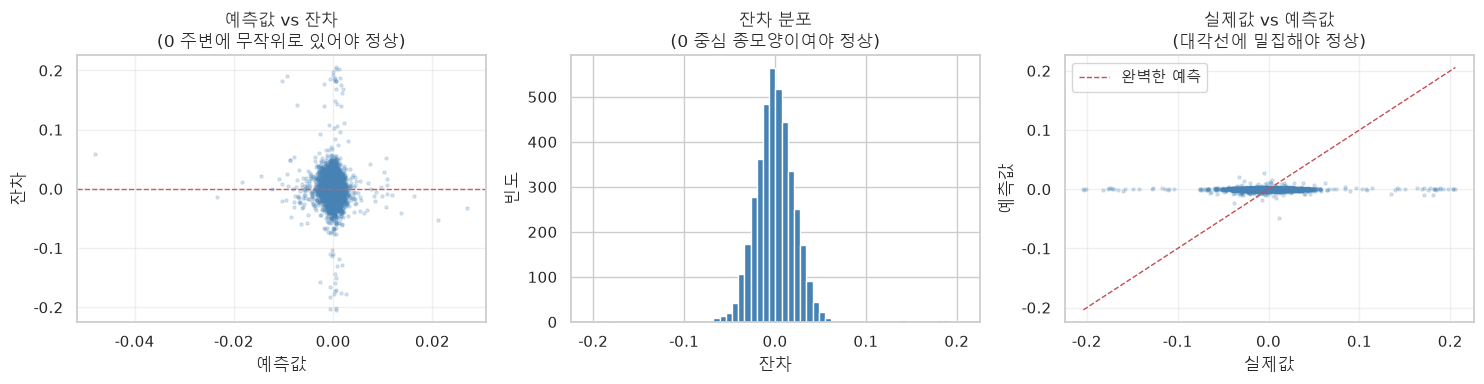

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# 1. 예측값 vs 잔차
axes[0].scatter(pred_best, residual, s=5, alpha=0.2, color="steelblue")
axes[0].axhline(0, color="indianred", ls="--", lw=1)
axes[0].set_xlabel("예측값")
axes[0].set_ylabel("잔차")
axes[0].set_title("예측값 vs 잔차\n(0 주변에 무작위로 있어야 정상)")
axes[0].grid(alpha=0.3)

# 2. 잔차 히스토그램
axes[1].hist(residual, bins=60, color="steelblue")
axes[1].axhline(0, color="indianred", ls="--", lw=1)
axes[1].set_xlabel("잔차")
axes[1].set_ylabel("빈도")
axes[1].set_title("잔차 분포\n(0 중심 종모양이여야 정상)")
axes[0].grid(alpha=0.3)

# 3. 실제값 vs 예측값
axes[2].scatter(y_test_회귀, pred_best, s=5, alpha=0.2, color="steelblue")
lo, hi = y_test_회귀.min(), y_test_회귀.max()
axes[2].plot([lo, hi], [lo, hi], "r--", lw=1, label="완벽한 예측")
axes[2].set_xlabel("실제값")
axes[2].set_ylabel("예측값")
axes[2].set_title("실제값 vs 예측값\n(대각선에 밀집해야 정상)")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()


**실제값 vs 예측값을 보면**

실제값은 -0.2~0.2로 넓게 퍼져있는데, 예측값은 전부 0근처에 좁게 몰려있다. -> 가로로납작  
이게 거의 설명하는 못한다의 시각적 모습이다. -> 모델이 사실상 예측을 하고있지 못한다.  
RMSE숫자로 확인해도 알 수 있다.

In [20]:
# 예측 구간별 잔차 패턴 확인

구간 = pd.qcut(pred_best, 5, labels=[f"Q{i}" for i in range(1, 6)], duplicates="drop")
분석 = pd.DataFrame({"예측" : pred_best, "잔차": residual, "구간" : 구간})

result = 분석.groupby("구간", observed=True).agg(
    예측평균=("예측", "mean"),
    잔차평균=("잔차", "mean"),
    잔차표준편차=('잔차', "std"),
    건수=("잔차", "size"),
)

print(result.round(6).to_string())
print()
print("잔차 평균이 구간마다 크게 다른가?")

        예측평균      잔차평균    잔차표준편차   건수
구간                                   
Q1 -0.002368  0.002506  0.025402  800
Q2 -0.000551  0.001475  0.025818  800
Q3  0.000006 -0.000401  0.025759  800
Q4  0.000510 -0.000723  0.032226  800
Q5  0.001774 -0.002381  0.026959  800

잔차 평균이 구간마다 크게 다른가?


**잔차에 패턴이 있으면 모델이 놓친 구조가 있는 것**

예측값이 클 때 잔차도 커진다면, 관계가 선형이 아니거나 중요한 피처가 빠진것.  
-> RMSE만 보면 절대 알 수 없다.  

한쪽으로 치우친 예측인 경우  
잔차 평균이 0이 아니라면 모델이 체계적으로 높게 또는 낮게 예측하고 있는 것이다.

---
# 트리모델은 알고있는 데이터 범위 밖의 값을 예측할 수 없다

내삽(알고있는 데이터 범위 안의 값)  
외삽(알고있는 데이터 범위 밖의 값)  
-> 학습데이터에서 본적없는 범위의 값이 들어오면 트리모델은 본적 있는 값의 평균을 내놓는다.  

> 학습 범위(x=10)를 넘어가면 더이상 값을 올릴 수 없다. 반면 선형회귀는 직선을 연장해서 예측이 가능하다.  
> 학습 데이터의 종가가 1만~50만원이었다면, 100만짜리 종목의 예측값은 50만원 근처가 나올 것이다.